# 04 - Feature Selection (Late Fusion Architecture)

This notebook demonstrates the Late Fusion feature selection pipeline:

**NEW ARCHITECTURE:** Two parallel branches instead of Early Fusion
1. **Genomic Branch:** MI + PSO on gene expression data ONLY
2. **Clinical Branch:** Domain-specific engineered features (Gleason, Stage, etc.) ONLY

> **CRITICAL:** Old 3-Layer/Early Fusion logic has been REMOVED

In [1]:
import sys
from pathlib import Path
import importlib
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import config
from src.io import save_dataframe, save_table
from src.genomic_selector import run_genomic_feature_selection, transform_genomic
from src.genomic_engineer import create_genomic_pathway_features
from src.clinical_selector import run_clinical_feature_selection, transform_clinical
from src.clinical_engineer import create_clinical_features, get_clinical_feature_names
from src.visualization import setup_style
setup_style()

## Step 1: Load Preprocessed Data and Split into Genomic/Clinical

In [2]:
X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
X_test = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

print(f"Train shape: {X_train.shape}, positives={int(y_train.sum())}")
print(f"Test shape:  {X_test.shape}, positives={int(y_test.sum())}")

Train shape: (343, 19019), positives=46
Test shape:  (86, 19019), positives=12


In [3]:
# Identify genomic vs clinical columns using the processed clinical schema
clinical_schema = pd.read_csv(config.CLINICAL_PROCESSED, nrows=0)
clinical_schema_cols = set(clinical_schema.columns) - {
    config.PATIENT_ID_COLUMN,
    config.TARGET_COLUMN,
}

CLINICAL_COLS = [c for c in X_train.columns if c in clinical_schema_cols]
GENE_COLS = [c for c in X_train.columns if c not in CLINICAL_COLS]

X_train_genomic = X_train[GENE_COLS]
X_train_clinical = X_train[CLINICAL_COLS]
X_test_genomic = X_test[GENE_COLS]
X_test_clinical = X_test[CLINICAL_COLS]

print(f"Genomic features: {len(GENE_COLS)}")
print(f"Clinical features: {len(CLINICAL_COLS)}")

Genomic features: 18905
Clinical features: 114


## Step 2: Genomic Branch - MI + PSO on Genes ONLY

In [4]:
genomic_selector, genomic_features = run_genomic_feature_selection(
    X_train_genomic,
    y_train,
    variance_threshold=config.VARIANCE_THRESHOLD,
    mi_top_k=config.MI_TOP_K,
    pso_final_k=config.PSO_FINAL_K,
    run_pso=True,
    random_state=config.RANDOM_STATE,
)

print(f"\nGenomic Branch: Selected {len(genomic_features)} genes")

2026-09-14 15:53:19 | INFO     | prostate_bcr | Genomic selector: 18905 variance → 200 MI features
2026-09-14 15:53:25 | INFO     | prostate_bcr | Genomic PSO: 12 particles, 10 iterations, target 40 features, alpha=0.0010
2026-09-14 15:53:44 | INFO     | prostate_bcr |   Genomic PSO iter 5/10: best Fitness=0.7710 (Raw AUC ~= 0.8110)
2026-09-14 15:54:04 | INFO     | prostate_bcr |   Genomic PSO iter 10/10: best Fitness=0.7821 (Raw AUC ~= 0.8221)
2026-09-14 15:54:04 | INFO     | prostate_bcr | Genomic PSO selected 40 features with final fitness=0.7821
2026-09-14 15:54:04 | INFO     | prostate_bcr | Genomic feature selection complete: 18905 → 200 → 40 features



Genomic Branch: Selected 40 genes


## Step 3: Clinical Branch - Create Engineered Features ONLY

In [5]:
X_train_clinical_eng, engineered_clinical_features = create_clinical_features(X_train_clinical)
X_test_clinical_eng, _ = create_clinical_features(X_test_clinical)

clinical_selector, clinical_features = run_clinical_feature_selection(
    X_train_clinical_eng,
    y_train,
    variance_threshold=config.VARIANCE_THRESHOLD,
    mi_top_k=config.MI_TOP_K,
    pso_final_k=config.PSO_FINAL_K,
    run_pso=True,
    random_state=config.RANDOM_STATE,
 )
X_train_clinical_selected = transform_clinical(
    X_train_clinical_eng, clinical_selector, clinical_features
 )
X_test_clinical_selected = transform_clinical(
    X_test_clinical_eng, clinical_selector, clinical_features
 )

print(f"Clinical engineered features: {len(engineered_clinical_features)}")
print(f"Clinical selected features: {len(clinical_features)}")
print(f"Features: {clinical_features}")

2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical: Gleason_Total, High_Risk_Gleason
2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical: Margin_x_LymphNode
2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical: T_Stage_Risk
2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical: Gleason_Total, High_Risk_Gleason
2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical: Margin_x_LymphNode
2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical: T_Stage_Risk
2026-09-14 15:54:04 | INFO     | prostate_bcr | Clinical selector: 81 variance -> 81 MI features
2026-09-14 15:54:08 | INFO     | prostate_bcr | Clinical PSO: 12 particles, 10 iterations, target 40 features, alpha=0.0010
2026-09-14 15:54:23 | INFO     | prostate_bcr |   Clinical PSO iter 5/10: best Fitness=0.7810 (Raw AUC ~= 0.8210)
2026-09-14 15:54:39 | INFO     | prostate_bcr |   Clinical PSO iter 10/10: best Fitness=0.7939 (Raw AUC ~= 0.8339)
2026-09-14 15:54:39 | INFO     | prostate_bcr | Clinical PSO selected 40

Clinical engineered features: 4
Clinical selected features: 40
Features: ['Person Neoplasm Status_WITH TUMOR', 'Primary Therapy Outcome Success Type_Progressive Disease', 'T_Stage_Risk', 'Gleason pattern tertiary_4', 'Did patient start adjuvant postoperative radiotherapy?_NO', 'Primary Therapy Outcome Success Type_Partial Remission/Response', 'Radical Prostatectomy Gleason Score for Prostate Cancer', 'International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code_8140/3', 'Neoplasm American Joint Committee on Cancer Clinical Primary Tumor T Stage_T3a', 'Positive Finding Lymph Node Hematoxylin and Eosin Staining Microscopy Count', 'Ct scan ab pelvis indicator_YES', 'Year Cancer Initial Diagnosis', 'American Joint Committee on Cancer Tumor Stage Code_T3b', 'Tissue Retrospective Collection Indicator_YES', 'Tissue Prospective Collection Indicator_NO', 'Gleason pattern secondary', 'Mri results_No Evidence of Extraprostatic Extension', 'Gleason pattern tertiary_3

## Step 4: Display Selected Genomic Features

In [6]:
genomic_df = pd.DataFrame({
    "rank": range(1, len(genomic_features) + 1),
    "feature": genomic_features,
})
print("Selected Genomic Features:")
print(genomic_df.to_string(index=False))

Selected Genomic Features:
 rank      feature
    1       RASSF2
    2         ASPA
    3        FTSJ2
    4      TMEM145
    5 DKFZp547O146
    6       CARD19
    7         CTRC
    8       ZNF324
    9         MUL1
   10         BOP1
   11          SP1
   12      SUGT1P1
   13      RPS2P32
   14        ZFP82
   15       EIF2B2
   16       MAGEL2
   17        BCRP3
   18        RACH1
   19        RC3H1
   20          FUS
   21      TXNDC11
   22      ZNF512B
   23        GLIS2
   24         AFF3
   25      SPATA41
   26        BRWD3
   27       BMS1P4
   28        NAA40
   29        EIF5B
   30        BAMBI
   31      PHACTR4
   32        DCAF4
   33        IFI16
   34        PARP2
   35      ANKRD45
   36      TMEM258
   37       SLC5A7
   38         MZF1
   39       CLECL1
   40        NBPF3


## Step 5: Mutual Information Scores (Top Genomic Features)

2026-09-14 15:54:39 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\genomic_mi_scores.png


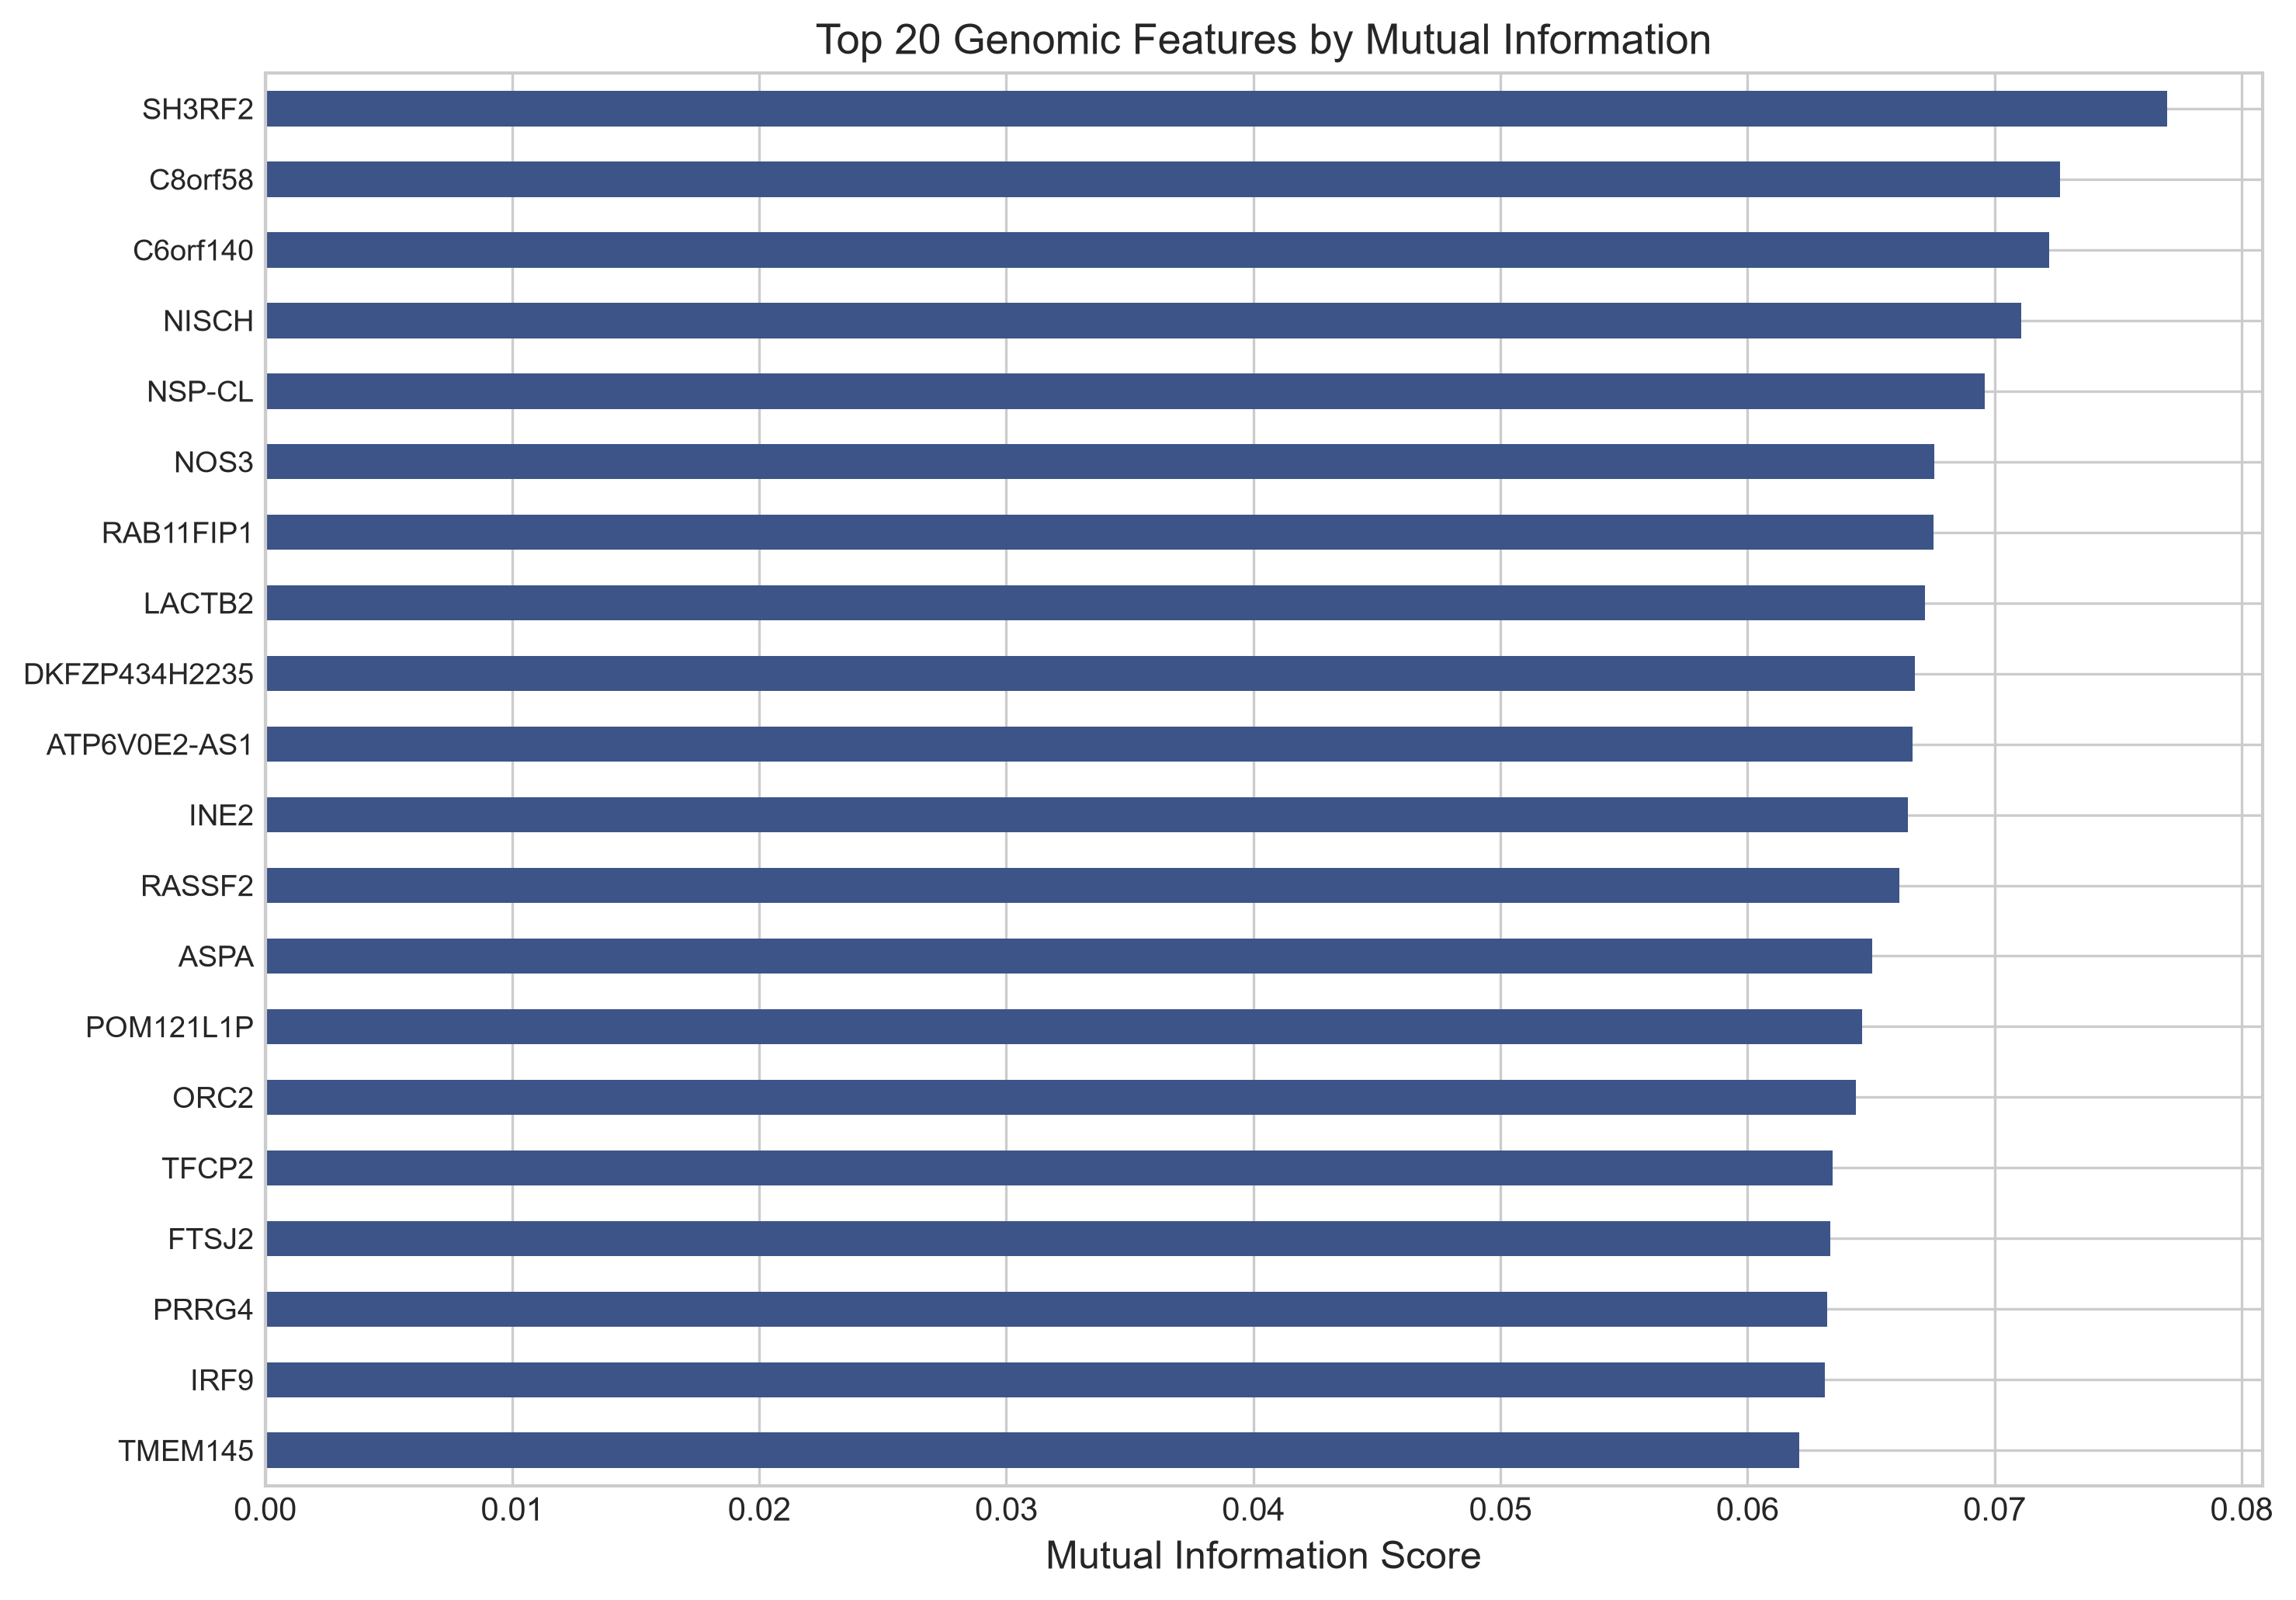

In [7]:
mi_scores = genomic_selector["mi_scores"]
top_mi = mi_scores.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_mi.sort_values().plot(kind="barh", ax=ax, color="#3C5488")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 20 Genomic Features by Mutual Information")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()

from src.io import save_figure
save_figure(fig, "genomic_mi_scores.png")
plt.show()

## Step 6: Transform Test Data Using Fitted Selectors

In [8]:
X_train_genomic_selected = transform_genomic(X_train_genomic, genomic_selector, genomic_features)
X_test_genomic_selected = transform_genomic(X_test_genomic, genomic_selector, genomic_features)

X_train_genomic_molecular, molecular_features = create_genomic_pathway_features(X_train_genomic)
X_test_genomic_molecular, _ = create_genomic_pathway_features(X_test_genomic)
X_train_genomic_selected = pd.concat(
    [X_train_genomic_selected, X_train_genomic_molecular[molecular_features]],
    axis=1,
 )
X_test_genomic_selected = pd.concat(
    [X_test_genomic_selected, X_test_genomic_molecular[molecular_features]],
    axis=1,
 )
genomic_features = genomic_features + molecular_features

print(f"Train genomic selected shape: {X_train_genomic_selected.shape}")
print(f"Test genomic selected shape:  {X_test_genomic_selected.shape}")
print(f"Molecular pathway features: {molecular_features}")

2026-09-14 15:54:40 | INFO     | prostate_bcr | Genomic: PSA_Pathway_Score (from 7 genes)
2026-09-14 15:54:40 | INFO     | prostate_bcr | Genomic: AR_Signaling_Score (from 8 genes)
2026-09-14 15:54:40 | INFO     | prostate_bcr | Genomic: Proliferation_Score (from 7 genes)
2026-09-14 15:54:40 | INFO     | prostate_bcr | Genomic: PSA_Pathway_Score (from 7 genes)
2026-09-14 15:54:40 | INFO     | prostate_bcr | Genomic: AR_Signaling_Score (from 8 genes)
2026-09-14 15:54:40 | INFO     | prostate_bcr | Genomic: Proliferation_Score (from 7 genes)


Train genomic selected shape: (343, 43)
Test genomic selected shape:  (86, 43)
Molecular pathway features: ['PSA_Pathway_Score', 'AR_Signaling_Score', 'Proliferation_Score']


## Step 7: Save Artifacts for Late Fusion

In [9]:
save_table(pd.DataFrame({"feature": genomic_features}), "genomic_features.csv", index=False)
save_table(pd.DataFrame({"feature": clinical_features}), "clinical_features.csv", index=False)

save_dataframe(X_train_genomic_selected, "X_train_genomic_selected.csv", index=False)
save_dataframe(X_test_genomic_selected, "X_test_genomic_selected.csv", index=False)
save_dataframe(X_train_clinical_selected, "X_train_clinical_engineered.csv", index=False)
save_dataframe(X_test_clinical_selected, "X_test_clinical_engineered.csv", index=False)

print("Saved:")
print(f"  - genomic_features.csv ({len(genomic_features)} genes/pathways)")
print(f"  - clinical_features.csv ({len(clinical_features)} selected features)")
print(f"  - X_train_genomic_selected.csv {X_train_genomic_selected.shape}")
print(f"  - X_test_genomic_selected.csv {X_test_genomic_selected.shape}")
print(f"  - X_train_clinical_engineered.csv {X_train_clinical_selected.shape}")
print(f"  - X_test_clinical_engineered.csv {X_test_clinical_selected.shape}")

2026-09-14 15:54:40 | INFO     | prostate_bcr | Saved 43 rows → D:\Prostate_BCR\core\outputs\tables\genomic_features.csv
2026-09-14 15:54:40 | INFO     | prostate_bcr | Saved 40 rows → D:\Prostate_BCR\core\outputs\tables\clinical_features.csv
2026-09-14 15:54:40 | INFO     | prostate_bcr | Saved 343 rows → D:\Prostate_BCR\core\data\processed\X_train_genomic_selected.csv
2026-09-14 15:54:40 | INFO     | prostate_bcr | Saved 86 rows → D:\Prostate_BCR\core\data\processed\X_test_genomic_selected.csv
2026-09-14 15:54:40 | INFO     | prostate_bcr | Saved 343 rows → D:\Prostate_BCR\core\data\processed\X_train_clinical_engineered.csv
2026-09-14 15:54:40 | INFO     | prostate_bcr | Saved 86 rows → D:\Prostate_BCR\core\data\processed\X_test_clinical_engineered.csv


Saved:
  - genomic_features.csv (43 genes/pathways)
  - clinical_features.csv (40 selected features)
  - X_train_genomic_selected.csv (343, 43)
  - X_test_genomic_selected.csv (86, 43)
  - X_train_clinical_engineered.csv (343, 40)
  - X_test_clinical_engineered.csv (86, 40)
